In [22]:
pip install rdkit deepchem numpy torch transformers scikit-learn statsmodels seaborn plotly umap-learn kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np

path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")
csv_path = os.path.join(path, "2022/heart_2022_no_nans.csv")

columns_to_drop = [
    'State', 'LastCheckupTime', 'RaceEthnicityCategory',
    'TetanusLast10Tdap', 'HadAngina', 'HadStroke',
    'ChestScan', 'DifficultyDressingBathing', 'DifficultyErrands',
    'DifficultyWalking', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
    'HadKidneyDisease'
]

df = pd.read_csv(csv_path).drop(columns=columns_to_drop)

# ── Encoding ────────────────────────────────────────────────
df_encoded = df.drop_duplicates().copy()

# Binary sex
df_encoded['Sex'] = df_encoded['Sex'].map({'Male': 0, 'Female': 1})

# Yes/No → 1/0
binary_cols = [
    'HadHeartAttack', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
    'HadDepressiveDisorder', 'HadArthritis', 'PhysicalActivities',
    'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
    'DifficultyConcentrating', 'HighRiskLastYear'
]

for col in binary_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# GeneralHealth ordinal
health_map = {
    'Excellent': 4,
    'Very good': 3,
    'Good': 2,
    'Fair': 1,
    'Poor': 0
}
df_encoded['GeneralHealth'] = df_encoded['GeneralHealth'].map(health_map)

# Diabetes (ordinal)
diabetes_map = {
    'No': 0,
    'Yes, but only during pregnancy (female)': 1,
    'No, pre-diabetes or borderline diabetes': 2,
    'Yes': 3
}
df_encoded['HadDiabetes'] = df_encoded['HadDiabetes'].map(diabetes_map).fillna(0).astype(int)

# Covid
df_encoded['CovidPos'] = df_encoded['CovidPos'].map({
    'Yes': 1.0,
    'Tested positive using home test without a health professional': 0.75,
    'No': 0
}).fillna(0).astype(int)

# Age (numeric)
df_encoded['AgeCategory'] = df_encoded['AgeCategory'].str.extract(r'Age (\d+)').fillna(80).astype(float)

smoker_map = {'Former smoker':1/3, 'Never smoked':0, 'Current smoker - now smokes every day':3/3, 'Current smoker - now smokes some days':2/3}
df_encoded['SmokerStatus'] = df_encoded['SmokerStatus'].map(smoker_map)

vape_map = {'Never used e-cigarettes in my entire life':0, 'Use them some days':2/3, 'Not at all (right now)':1/3, 'Use them every day':3/3}
df_encoded['ECigaretteUsage'] = df_encoded['ECigaretteUsage'].map(vape_map)

teeth_map = {'None of them':0, '6 or more, but not all':2/3, '1 to 5':1/3, 'All':3/3}
df_encoded['RemovedTeeth'] = df_encoded['RemovedTeeth'].map(teeth_map)

#normalize valuees
df_encoded['AgeCategory'] = df_encoded['AgeCategory'].apply(lambda x: x/80)
df_encoded['WeightInKilograms'] = df_encoded['WeightInKilograms'].apply(lambda x: x/80)
df_encoded['BMI'] = df_encoded['BMI'].apply(lambda x: x/30)
df_encoded['MentalHealthDays'] = df_encoded['MentalHealthDays'].apply(lambda x: x/30)
df_encoded['PhysicalHealthDays'] = df_encoded['PhysicalHealthDays'].apply(lambda x: x/30)
df_encoded['SleepHours'] = df_encoded['SleepHours'].apply(lambda x: x/9)
df_encoded['HeightInMeters'] = df_encoded['HeightInMeters'].apply(lambda x: x/2)


# Quick sanity check
print("Shape:", df_encoded.shape)
print("\nFirst 5 rows:")
pd.set_option('display.max_columns', None)
print(df_encoded.head())

# Combined check
problem_cols = []

for col in df_encoded.columns:
    has_nan = df_encoded[col].isna().any()
    is_string_like = df_encoded[col].dtype == 'object' or df_encoded[col].dtype.name == 'category'
    
    if has_nan or is_string_like:
        problem_cols.append(col)
        print(f"→ {col}")
        if has_nan:
            print(f"   - Has NaN: {df_encoded[col].isna().sum()} rows")
        if is_string_like:
            print(f"   - Still string-like (dtype: {df_encoded[col].dtype})")
            print(f"   - Sample values: {df_encoded[col].dropna().unique()[:4].tolist()} ...")
        print()

if not problem_cols:
    print("Great! No columns with NaN or string/object dtypes remaining.")


X = df_encoded.drop(columns=["HadHeartAttack"]).values.astype(np.float32)
y = df_encoded["HadHeartAttack"].values.reshape(-1, 1).astype(np.float32)


x_train, x_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.10, random_state=123, shuffle=True
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=123, shuffle=True
)

# Compute mean and std from training data
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

# Avoid division by zero
std[std == 0] = 1

# Apply normalization
'''x_train_norm = (x_train - mean) / std
x_val_norm   = (x_val - mean) / std
x_test_norm  = (x_test - mean) / std'''


Shape: (245593, 27)

First 5 rows:
   Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
0    1              3            0.133333               0.0   
1    0              3            0.000000               0.0   
2    0              3            0.000000               0.0   
3    1              1            0.166667               0.0   
4    1              2            0.100000               0.5   

   PhysicalActivities  SleepHours  RemovedTeeth  HadHeartAttack  HadAsthma  \
0                   1    1.000000      0.000000               0          0   
1                   1    0.666667      0.000000               0          0   
2                   0    0.888889      0.666667               0          0   
3                   1    1.000000      0.000000               0          0   
4                   1    0.555556      0.333333               0          0   

   HadSkinCancer  HadCOPD  HadDepressiveDisorder  HadArthritis  HadDiabetes  \
0              0        0             

'x_train_norm = (x_train - mean) / std\nx_val_norm   = (x_val - mean) / std\nx_test_norm  = (x_test - mean) / std'

In [24]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from numpy.random import randn

class SingleLayerNN:
    def __init__(self, in_len, h_len, o_len, optimizer):
        self.in_len = in_len
        self.h_len = h_len
        self.o_len = o_len
        np.random.seed(123)
        #generate initial model parameters from a small gaussian distribution
        self.hidden_w = np.random.randn(in_len, h_len)*0.1
        self.hidden_b = np.zeros(h_len)

        self.output_w = np.random.randn(h_len, o_len) * 0.1
        self.output_b = np.zeros(o_len)

        self.optimizer = optimizer

    #leaky relu applied to hidden layers
    def hidden_activation(self, x):
        return np.maximum(x*0.01, x)

    # gradient of the hidden layer
    def hidden_grad(self, x):
        dx = np.ones_like(x)
        dx[x <= 0] = 0.01
        return dx

    # sigmoid with stability
    def output_activation(self, x):
        return np.clip(1 / (1 + np.exp(-x)), 1e-7, 1 - 1e-7)

    # compute the forward pass: inference + storing hidden values/bias value
    def forward(self, x):
        self.x = x #What the inputs were
        self.z1 = x @ self.hidden_w + self.hidden_b #What the hidden layer before activation was
        self.h = self.hidden_activation(self.z1) #Hidden layer after activation

        self.z2 = self.h @ self.output_w + self.output_b #output before activation
        self.y_hat = self.output_activation(self.z2) #output after activation / final prediction
        return self.y_hat

    #BCE loss
    def loss(self, y_hat, y):
        y_hat = np.clip(y_hat, 1e-7, 1 - 1e-7)
        return -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

    def backward(self, y):
        m = y.shape[0]

        #gradient on output hidden layer
        dL_dz2 = self.y_hat - y

        #compute change in loss WRT second layer of weights and biases
        dL_dW2 = (self.h.T @ dL_dz2) / m
        dL_db2 = np.mean(dL_dz2, axis=0)

        #hidden layer gradients
        dL_dh = dL_dz2 @ self.output_w.T
        dL_dz1 = dL_dh * self.hidden_grad(self.z1)

        #compute change in loss WRT first layer of weights and biases
        dL_dW1 = (self.x.T @ dL_dz1) / m
        dL_db1 = np.mean(dL_dz1, axis=0)

        #perform gradient descent on the partial derivatives calculated above
        params = [self.output_w, self.output_b, self.hidden_w, self.hidden_b]
        grads = [dL_dW2, dL_db2, dL_dW1, dL_db1]
        updated_params = self.optimizer.update(params, grads)
        self.output_w, self.output_b, self.hidden_w, self.hidden_b = updated_params

    def make_batches(self, x, y, batch_size):
        n = x.shape[0]
        idx = np.random.permutation(n)
        batches = []
        for i in range(0, n, batch_size):
            batch_idx = idx[i:i + batch_size]
            batches.append((x[batch_idx], y[batch_idx]))
        return batches

    def train(self, epochs, x, y, batch_size=32):
        n = x.shape[0]
        for i in range(epochs):
            epoch_loss = 0
            num_batches = 0
            for x_batch, y_batch in self.make_batches(x, y, batch_size):
                preds = self.forward(x_batch)
                self.backward(y_batch)
                epoch_loss += self.loss(preds, y_batch)
                num_batches += 1
            epoch_loss /= num_batches
            if i % 100 == 0:
                print(f"Epoch {i}, Loss: {epoch_loss:.4f}")

    def predict(self, x):
        #we could optimize this by not having to store the hidden values during inference but this is fine.
        return self.forward(x)
        
class SGDMomentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        # set velocity to 0 if not existant
        if self.v is None:
            self.v = [np.zeros_like(p) for p in params]

        #update the velocities/parameters
        self.v = [self.momentum * v - self.lr * g for v, g in zip(self.v, grads)]
        params = [p + v for p, v in zip(params, self.v)]

        return params


In [25]:
net = SingleLayerNN(X.shape[1], 40, 1, SGDMomentum(0.5,0.9))
net.train(101, x_train, y_train, (X.shape[0]+1)//8)

Epoch 0, Loss: 0.3093
Epoch 100, Loss: 0.1712


In [26]:
def evaluate_model(model, x_test, y_test, threshold=0.5):
    # Get probabilities from your network
    probs = model.predict(x_test).ravel()

    # Convert to class labels
    y_pred = (probs >= threshold)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs)
    }

    return metrics, y_pred, probs
print(evaluate_model(net, x_val, y_val, .5)[0])

{'accuracy': 0.9445439739413681, 'precision': 0.3333333333333333, 'recall': 0.0029455081001472753, 'f1': 0.00583941605839416, 'roc_auc': 0.8237696994025323}


I used minibatch gradient descent since it allows most versatility and tradeoffs for speed vs gradient approximation. I also used SGD with momentum because otherwise convergence was extremely slow, and this is a very simple optimizer that can greatly enhance performance. 
Results: {'accuracy': 0.9427688805788147, 'precision': 0.6, 'recall': 0.0084985835694051, 'f1': 0.01675977653631285, 'roc_auc': np.float64(0.8280494791762104)}
With Normalization: {'accuracy': 0.9447068403908795, 'precision': 0.5, 'recall': 0.005891016200294551, 'f1': 0.011644832605531296, 'roc_auc': 0.8243386920456174}
These results reflect a tiny advantage over guessing purely 0 (no heart attack.)

### Task 2
Data cleaning/splitting/normalization was performed in the first code block where I had to encode multiple different classes into one hot or using a scaling system.

Normalization did not seem to have a significant impact, although it might slightly improve model performance. This is most likely because I already performed significant data preprocessing and scaling

Using 50000 samples for visualization


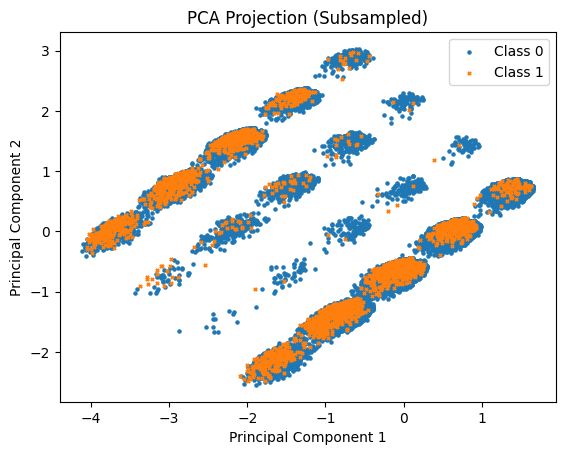

C:\Users\James\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


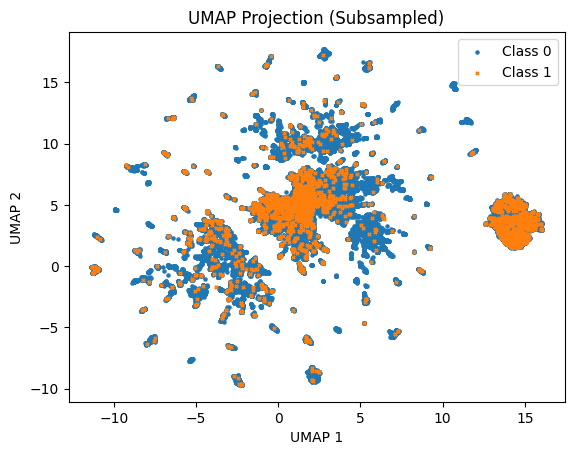

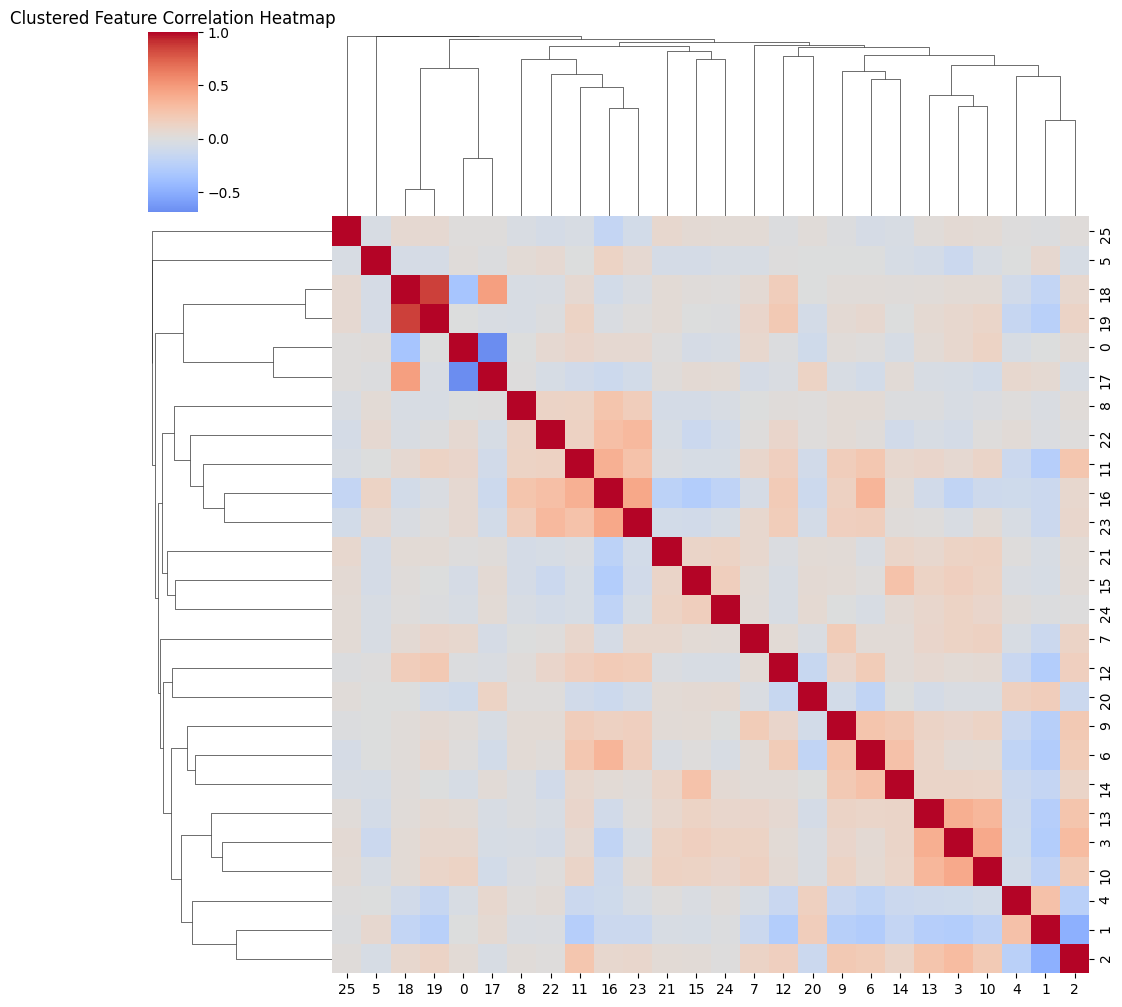

In [27]:
# Visualization (PCA + UMAP with Subsampling)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import umap

# Convert to numpy and fix shape
X = np.array(x_train)
y = np.array(y_train).ravel()

# -----------------------------
# Subsample for speed
# -----------------------------
max_points = 50000  # adjust if needed

if len(X) > max_points:
    idx = np.random.choice(len(X), max_points, replace=False)
    X_vis = X[idx]
    y_vis = y[idx]
else:
    X_vis = X
    y_vis = y

print(f"Using {len(X_vis)} samples for visualization")

# =============================
# PCA
# =============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

plt.figure()
plt.scatter(X_pca[y_vis == 0, 0], X_pca[y_vis == 0, 1], marker='o', s=5)
plt.scatter(X_pca[y_vis == 1, 0], X_pca[y_vis == 1, 1], marker='x', s=5)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (Subsampled)")
plt.legend(["Class 0", "Class 1"])
plt.show()


# =============================
# UMAP
# =============================
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_vis)

plt.figure()
plt.scatter(X_umap[y_vis == 0, 0], X_umap[y_vis == 0, 1], marker='o', s=5)
plt.scatter(X_umap[y_vis == 1, 0], X_umap[y_vis == 1, 1], marker='x', s=5)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Projection (Subsampled)")
plt.legend(["Class 0", "Class 1"])
plt.show()

# =============================
# Clustered Correlation Heatmap
# =============================

import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

# Optional: limit number of features if extremely high-dimensional
max_features = 200  # adjust if needed

if X_vis.shape[1] > max_features:
    X_corr = X_vis[:, :max_features]
    print(f"Using first {max_features} features for correlation heatmap")
else:
    X_corr = X_vis

# Compute correlation matrix
corr_matrix = np.corrcoef(X_corr, rowvar=False)

# Convert correlation to distance for clustering
distance_matrix = 1 - np.abs(corr_matrix)

# Hierarchical clustering
linkage_matrix = linkage(squareform(distance_matrix, checks=False), method='average')

# Plot clustered heatmap
sns.clustermap(
    corr_matrix,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(10, 10)
)

plt.title("Clustered Feature Correlation Heatmap")
plt.show()



In [28]:
import torch
import torch.nn as nn
import torch.optim as optim

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print("Using device:", device)

# Define the 2-layer model
class BinaryClassifier(nn.Module):
    def __init__(self):
        super(BinaryClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(26, 26),
            nn.LeakyReLU(),
            nn.Linear(26, 26),
            nn.LeakyReLU(),
             nn.Linear(26, 26),
            nn.LeakyReLU(),
            nn.Linear(26, 1),
            nn.Sigmoid()  # For binary output
        )

    def forward(self, x):
        return self.layers(x)

model = BinaryClassifier().to(device)

# Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Convert data to PyTorch tensors
x_train_t = torch.tensor(x_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32).to(device)
x_val_t = torch.tensor(x_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32).to(device)

# Training loop
epochs = 200
batch_size = (x_train_t.size()[0]+1)//32
#batch_size = 8

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(x_train_t.size(0))
    
    for i in range(0, x_train_t.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_train_t[indices], y_train_t[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_pred = (val_outputs > 0.5).float()
        val_acc = (val_pred == y_val_t).sum() / y_val_t.size(0)
    
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {loss.item():.4f}, "
          f"Val Loss: {val_loss.item():.4f}, "
          f"Val Acc: {val_acc.item():.4f}")


Using device: cpu
Epoch 1/200, Train Loss: 0.3956, Val Loss: 0.1943, Val Acc: 0.9447
Epoch 2/200, Train Loss: 0.6946, Val Loss: 0.1846, Val Acc: 0.9447
Epoch 3/200, Train Loss: 0.0680, Val Loss: 0.1822, Val Acc: 0.9447
Epoch 4/200, Train Loss: 0.0663, Val Loss: 0.1800, Val Acc: 0.9447
Epoch 5/200, Train Loss: 0.0521, Val Loss: 0.1792, Val Acc: 0.9447
Epoch 6/200, Train Loss: 0.0602, Val Loss: 0.1794, Val Acc: 0.9447
Epoch 7/200, Train Loss: 0.0267, Val Loss: 0.1782, Val Acc: 0.9447
Epoch 8/200, Train Loss: 0.2226, Val Loss: 0.1783, Val Acc: 0.9447
Epoch 9/200, Train Loss: 0.0453, Val Loss: 0.1787, Val Acc: 0.9447
Epoch 10/200, Train Loss: 0.0477, Val Loss: 0.1785, Val Acc: 0.9447
Epoch 11/200, Train Loss: 0.0424, Val Loss: 0.1792, Val Acc: 0.9447
Epoch 12/200, Train Loss: 0.6462, Val Loss: 0.1822, Val Acc: 0.9448
Epoch 13/200, Train Loss: 0.3657, Val Loss: 0.1805, Val Acc: 0.9447
Epoch 14/200, Train Loss: 0.0550, Val Loss: 0.1801, Val Acc: 0.9447
Epoch 15/200, Train Loss: 0.0328, Val L

In [29]:
# Convert test data to PyTorch tensors
x_test_t = torch.tensor(x_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32).to(device)

# Evaluation on test set
model.eval()
with torch.no_grad():
    test_outputs = model(x_test_t)
    test_loss = criterion(test_outputs, y_test_t)
    
    # Convert probabilities to binary predictions
    test_pred = (test_outputs > 0.5).float()
    
    # Accuracy
    test_acc = (test_pred == y_test_t).sum() / y_test_t.size(0)
    
    # Confusion matrix components
    TP = ((test_pred == 1) & (y_test_t == 1)).sum().item()
    TN = ((test_pred == 0) & (y_test_t == 0)).sum().item()
    FP = ((test_pred == 1) & (y_test_t == 0)).sum().item()
    FN = ((test_pred == 0) & (y_test_t == 1)).sum().item()
    
    # Precision, Recall, F1
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

print("Test Loss:", test_loss.item())
print("Test Accuracy:", test_acc.item())
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:")
print(f"TP: {TP}, FP: {FP}")
print(f"FN: {FN}, TN: {TN}")


Test Loss: 0.1716272383928299
Test Accuracy: 0.9470683932304382
Precision: 0.9999999983333333
Recall: 0.009146341463275209
F1 Score: 0.01812688803734906
Confusion Matrix:
TP: 6, FP: 0
FN: 650, TN: 11624
